# Marker Neighborhood Figures

This notebook refines the old `legacy/nonlocal_analysis_ensemble_targeted.ipynb` workflow using the current preprocessed graph files and `organograph.graph.stats` helpers. It loads both datasets, pools matching timepoints across datasets including `day4p5-more` as `day 4.5`, and produces marker-neighborhood figures for the direct-neighbor graph (`k=1`).

## Imports

In [12]:
# Re-run from here if you change the configuration below.
import os
import glob
import hashlib
import json
import pickle
import warnings
from functools import lru_cache
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from organograph.graph.io import load_cell_graph
from organograph.graph.access import graph_get
from organograph.graph.stats import (
    build_weight_matrix_kNN,
    compute_morans_I,
)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "axes.spines.top": True,
    "axes.spines.right": True,
})


def box_on(ax):
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
    ax.tick_params(top=False, right=False)

## Configuration

By default this uses `graphs_preprocessed`, because that graph folder contains all requested timepoints in the two datasets. `day4p5-more` is included and pooled under `day 4.5`. Figures are restricted to the exact entries listed in `SELECTED_TIMEPOINTS`.

In [13]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"notebooks", "notebooks_dev", "legacy"}:
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT.parent / "NicoleData"

NOTEBOOK_NAME = "plot_marker_neighborhood"
EXPORT_DIR = PROJECT_ROOT / "exports" / NOTEBOOK_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def export_figure(fig, filename):
    """Save a Matplotlib figure as a tightly cropped PDF in the notebook export folder."""
    safe_name = "".join(
        char if char.isalnum() or char in {"_", "-"} else "_"
        for char in str(filename)
    ).strip("_")
    path = EXPORT_DIR / f"{safe_name}.pdf"
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path

# -----------------------------------------------------------------------------
# Shared data/loading settings used by all retained figures.
# -----------------------------------------------------------------------------
DATASETS = "20250929" # ["20250929", "20251201"]
GRAPH_SUBDIR = "graphs_preprocessed"
SELECTED_TIMEPOINTS = ["day4p5", "day4p5-more"]  # Exact graph timepoint folders to analyze; None uses all.
MIN_TIMEPOINT_NUMERIC = None  # Optional extra lower bound; e.g. 4.5 uses only this timepoint and later.
MAX_GRAPHS_PER_TIMEPOINT = None  # e.g. 20 for a quick smoke run; None uses all graphs.
RANDOM_SEED = 7
DERIVED_MARKERS = {}

# -----------------------------------------------------------------------------
# Optional marker preprocessing applied after graph loading and before analysis.
# The raw graph marker fields are not modified; these settings define the
# effective marker matrix used by all figures below.
# -----------------------------------------------------------------------------
ENABLE_MARKER_HARMONIZATION = True
MARKER_HARMONIZATION_RULES = {
    # Treat the old Cyclin A/D proliferation panel and the newer KI67 panel as
    # one effective marker named KI67. Disable or edit this if you want strict
    # per-antibody marker identities.
    "KI67": ["KI67", "Cyclin A", "Cyclin D"],
}
MARKER_HARMONIZATION_KEEP_UNMAPPED = True

ENABLE_MARKER_EXCLUSIVITY = True
EXCLUSIVITY_RULES = {
    "LGR5":     ["Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "Chroma":   ["Mucin 2", "Glucagon", "Serotonin", "Lysozyme"],
    "Mucin 2":  ["Chroma", "Glucagon", "Serotonin", "Lysozyme"],
    "AldoB":    ["Chroma", "Mucin 2", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "Glucagon": ["Serotonin"],
    "Agr2":     ["Chroma", "Mucin 2", "Glucagon", "Serotonin", "Lysozyme"],
    "Serotonin":[],
    "Lysozyme": ["Chroma", "Glucagon", "Serotonin"],
    "Cyclin D": ["LGR5", "Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "Cyclin A": ["LGR5", "Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "KI67":     ["LGR5", "Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
}
EXCLUSIVITY_INCLUDE_UNASSIGNED = True
EXCLUSIVITY_UNASSIGNED_LABEL = "unassigned"

CACHE_DIR = PROJECT_ROOT / "notebooks_dev" / ".cache_marker_neighborhood"
CACHE_DIR.mkdir(exist_ok=True)
USE_CACHE = False

# -----------------------------------------------------------------------------
# Figure 1: Moran's I with permutation nulls.
# Controls the cross-Moran source/target marker pairs, graph-neighborhood k,
# row standardization of W, and the number of shuffled-label null permutations.
# -----------------------------------------------------------------------------
MORAN_K_VALUES = [1]
MORAN_N_PERMS = 999  # Increase to 999 for final figures if runtime is acceptable.
MORAN_ROW_STANDARDIZE_W = False
MORAN_NULL_Q = (2.5, 97.5)
MORAN_ANALYSES = [
    {
        "name": "cell-type markers",
        "sources": ["Serotonin", "Lysozyme"],
        "targets": ["LGR5", "Serotonin", "Lysozyme"],
    },
]

# -----------------------------------------------------------------------------
# Figure 2: fraction of k-hop neighbors positive with shuffled expectation.
# Controls focal/target markers, the graph-hop k values, the number of null
# permutations used for expected neighbor fractions.
# -----------------------------------------------------------------------------
KHOP_K_VALUES = [1]
KHOP_PLOT_K = 1
KHOP_CENTER_MARKER = "LGR5"
KHOP_FOCAL_MARKERS = [KHOP_CENTER_MARKER]
MARKER_PANEL_TARGETS = ["LGR5", "Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme", "KI67"]
KHOP_TARGET_MARKERS = list(MARKER_PANEL_TARGETS)
if ENABLE_MARKER_EXCLUSIVITY and EXCLUSIVITY_INCLUDE_UNASSIGNED:
    KHOP_TARGET_MARKERS.append(EXCLUSIVITY_UNASSIGNED_LABEL)
KHOP_EXPECTED_N_PERMS = 7  # Increase to 999 for final figures if runtime is acceptable.

# -----------------------------------------------------------------------------
# Figure 3: enrichment as a function of graph distance with shuffled null ribbon.
# Controls source-target marker pairs, maximum graph distance, number of null
# permutations, percentile interval for the ribbon, and the first hop plotted.
# -----------------------------------------------------------------------------
HOP_ENRICHMENT_CENTER_MARKER = KHOP_CENTER_MARKER
HOP_ENRICHMENT_TARGET_MARKERS = KHOP_TARGET_MARKERS
HOP_ENRICHMENT_PAIRS = [(HOP_ENRICHMENT_CENTER_MARKER, target) for target in HOP_ENRICHMENT_TARGET_MARKERS]
HOP_ENRICHMENT_MAX_HOPS = 6
HOP_NULL_PERMS = 999
HOP_NULL_Q = (2.5, 97.5)
HOP_MIN_HOP = 1


## Load Graph Index

The table below is one row per graph file. Identical timepoints across datasets are intentionally assigned the same `sample_label`, so later plots pool those rows.

In [14]:
def timepoint_to_float(tp):
    return float(str(tp).replace("day", "").replace("p", ".").replace("-more", ""))


def timepoint_label(tp):
    return f"day {timepoint_to_float(tp):g}"


def normalize_dataset_names(datasets):
    """Accept either a single dataset name or a list/tuple of dataset names."""
    if isinstance(datasets, (str, Path)):
        return [str(datasets)]
    return [str(dataset) for dataset in datasets]


def normalize_timepoint_names(timepoints):
    """Accept None, one timepoint folder, or a list/tuple of timepoint folders."""
    if timepoints is None:
        return None
    if isinstance(timepoints, (str, Path)):
        return {str(timepoints)}
    return {str(timepoint) for timepoint in timepoints}


def resolve_graph_path(path_value, dataset, graph_subdir, timepoint, label_uid=None):
    path = Path(str(path_value)) if pd.notna(path_value) else None
    if path is not None and path.exists():
        return path

    candidates = []
    if label_uid:
        candidates.append(DATA_ROOT / dataset / graph_subdir / timepoint / f"{label_uid}.gpickle")
    if path is not None:
        candidates.append(DATA_ROOT / dataset / graph_subdir / timepoint / path.name)

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return path


def discover_graphs(data_root=DATA_ROOT, datasets=DATASETS, graph_subdir=GRAPH_SUBDIR, selected_timepoints=SELECTED_TIMEPOINTS):
    dataset_names = normalize_dataset_names(datasets)
    selected = normalize_timepoint_names(selected_timepoints)
    rows = []
    for dataset in dataset_names:
        root = data_root / dataset / graph_subdir
        if not root.exists():
            warnings.warn(f"Missing graph directory: {root}")
            continue

        for tp_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
            tp = tp_dir.name
            if selected is not None and tp not in selected:
                continue

            index_path = tp_dir / "index.csv"
            if index_path.exists():
                df = pd.read_csv(index_path)
                for _, row in df.iterrows():
                    label_uid = row.get("label_uid", Path(str(row.get("graph_path", ""))).stem)
                    graph_path = resolve_graph_path(row.get("graph_path"), dataset, graph_subdir, tp, label_uid)
                    if graph_path is None or not Path(graph_path).exists():
                        continue
                    rows.append({
                        "dataset": dataset,
                        "timepoint": tp,
                        "sample_label": timepoint_label(tp),
                        "time_numeric": timepoint_to_float(tp),
                        "label_uid": label_uid,
                        "graph_path": str(graph_path),
                        "N_cells": row.get("N_cells", np.nan),
                    })
            else:
                for graph_path in sorted(tp_dir.glob("*.gpickle")):
                    rows.append({
                        "dataset": dataset,
                        "timepoint": tp,
                        "sample_label": timepoint_label(tp),
                        "time_numeric": timepoint_to_float(tp),
                        "label_uid": graph_path.stem,
                        "graph_path": str(graph_path),
                        "N_cells": np.nan,
                    })

    table = pd.DataFrame(rows)
    if table.empty:
        raise FileNotFoundError(f"No graph files found under {data_root} for {dataset_names} / {graph_subdir} / selected_timepoints={selected}")

    table = table.sort_values(["time_numeric", "dataset", "label_uid"]).reset_index(drop=True)
    if MIN_TIMEPOINT_NUMERIC is not None:
        table = table[table["time_numeric"] >= float(MIN_TIMEPOINT_NUMERIC)].reset_index(drop=True)
    if table.empty:
        raise FileNotFoundError(f"No graph files remain after timepoint filtering under {data_root}")
    if MAX_GRAPHS_PER_TIMEPOINT is not None:
        table = (
            table.groupby(["dataset", "timepoint"], group_keys=False, sort=False)
            .head(int(MAX_GRAPHS_PER_TIMEPOINT))
            .reset_index(drop=True)
        )
    return table


def filter_to_plot_timepoints(df):
    """Restrict cached or computed result tables to the configured plotting timepoints."""
    if df is None or df.empty:
        return df
    out = df.copy()
    selected = normalize_timepoint_names(SELECTED_TIMEPOINTS)
    if selected is not None and "timepoint" in out.columns:
        out = out[out["timepoint"].astype(str).isin(selected)]
    if MIN_TIMEPOINT_NUMERIC is not None and "time_numeric" in out.columns:
        out = out[out["time_numeric"] >= float(MIN_TIMEPOINT_NUMERIC)]
    if "sample_label" in out.columns:
        out = out[out["sample_label"].isin(TIMEPOINT_ORDER)]
    return out.reset_index(drop=True)


graph_table = discover_graphs()
TIMEPOINT_ORDER = (
    graph_table[["sample_label", "time_numeric"]]
    .drop_duplicates()
    .sort_values("time_numeric")["sample_label"]
    .tolist()
)

display(graph_table.groupby(["sample_label", "dataset", "timepoint"]).size().rename("n_graphs").reset_index())
print("Pooled timepoint order:", TIMEPOINT_ORDER)
print(f"Total graphs: {len(graph_table)}")

,sample_label,dataset,timepoint,n_graphs
0,day 4.5,20250929,day4p5,120
1,day 4.5,20250929,day4p5-more,507


Pooled timepoint order: ['day 4.5']
Total graphs: 627


## Marker Helpers

Marker names are resolved from each graph and then optionally harmonized and converted to exclusive cell-type labels according to the configuration cell. `Chroma`/`ChromA` aliases are handled so the two datasets can be analyzed together.


In [15]:
@lru_cache(maxsize=2048)
def load_graph_cached(graph_path):
    G = load_cell_graph(str(graph_path))
    # The current graph builder uses nodes 0..N-1; this keeps older or unusual files aligned with graph_get.
    if set(G.nodes()) != set(range(G.number_of_nodes())):
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    return G


def _as_bool_marker_matrix(markers):
    X = np.asarray(markers)
    if X.ndim != 2:
        raise ValueError(f"Expected a 2D marker matrix, got shape {X.shape}")
    return X > 0


def marker_preprocess_cache_tag():
    """Stable tag for caches that depend on effective marker preprocessing."""
    payload = {
        "harmonization_enabled": bool(ENABLE_MARKER_HARMONIZATION),
        "harmonization_rules": MARKER_HARMONIZATION_RULES if ENABLE_MARKER_HARMONIZATION else {},
        "harmonization_keep_unmapped": bool(MARKER_HARMONIZATION_KEEP_UNMAPPED),
        "exclusivity_enabled": bool(ENABLE_MARKER_EXCLUSIVITY),
        "exclusivity_rules": EXCLUSIVITY_RULES if ENABLE_MARKER_EXCLUSIVITY else {},
        "include_unassigned": bool(EXCLUSIVITY_INCLUDE_UNASSIGNED),
        "unassigned_label": EXCLUSIVITY_UNASSIGNED_LABEL,
    }
    text = json.dumps(payload, sort_keys=True)
    return hashlib.md5(text.encode("utf-8")).hexdigest()[:10]


def marker_alias_candidates(marker_name):
    marker = str(marker_name)
    aliases = {
        "ChromA": ["ChromA", "Chroma", "Chromogranin A", "ChromograninA"],
        "Chroma": ["Chroma", "ChromA", "Chromogranin A", "ChromograninA"],
        "Chromogranin A": ["Chromogranin A", "ChromograninA", "ChromA", "Chroma"],
        "ChromograninA": ["ChromograninA", "Chromogranin A", "ChromA", "Chroma"],
    }
    out = list(aliases.get(marker, [marker]))

    if ENABLE_MARKER_HARMONIZATION:
        for harmonized, sources in MARKER_HARMONIZATION_RULES.items():
            if marker == harmonized and harmonized not in out:
                out.append(harmonized)
            if marker == harmonized:
                out.extend([s for s in sources if s not in out])
            if marker in sources and harmonized not in out:
                out.append(harmonized)

    # Stable de-duplication while preserving order.
    deduped = []
    for alias in out:
        if alias not in deduped:
            deduped.append(alias)
    return deduped


def marker_name_to_index(marker_names):
    return {str(name).strip().lower(): i for i, name in enumerate(marker_names)}


def resolve_marker_indices(marker_names, requested):
    name_to_idx = marker_name_to_index(marker_names)
    idx = []
    for marker in requested:
        for alias in marker_alias_candidates(marker):
            key = str(alias).strip().lower()
            if key in name_to_idx and name_to_idx[key] not in idx:
                idx.append(name_to_idx[key])
                break
    return idx


def marker_consumed_by_harmonization(marker_name):
    """Return True when marker_name was folded into another harmonized output."""
    if not ENABLE_MARKER_HARMONIZATION:
        return False
    marker_key = str(marker_name).strip().lower()
    for out_name, source_names in MARKER_HARMONIZATION_RULES.items():
        out_key = str(out_name).strip().lower()
        for source_name in source_names:
            if str(source_name).strip().lower() == marker_key and marker_key != out_key:
                return True
    return False


def harmonize_marker_matrix(markers_bin, marker_names):
    """Optionally combine marker columns according to MARKER_HARMONIZATION_RULES."""
    X = _as_bool_marker_matrix(markers_bin)
    names = list(marker_names)
    if not ENABLE_MARKER_HARMONIZATION or not MARKER_HARMONIZATION_RULES:
        return X.astype(float), names

    used_source_indices = set()
    harmonized_cols = []
    harmonized_names = []
    for out_name, source_names in MARKER_HARMONIZATION_RULES.items():
        idx = resolve_marker_indices(names, source_names)
        if not idx:
            continue
        used_source_indices.update(idx)
        harmonized_cols.append(np.any(X[:, idx], axis=1))
        harmonized_names.append(str(out_name))

    cols = []
    out_names = []
    if MARKER_HARMONIZATION_KEEP_UNMAPPED:
        for i, name in enumerate(names):
            if i in used_source_indices:
                continue
            cols.append(X[:, i])
            out_names.append(str(name))

    for name, col in zip(harmonized_names, harmonized_cols):
        # If a harmonized output name already exists from an unmapped marker, merge rather than duplicate.
        key = str(name).strip().lower()
        existing = [i for i, n in enumerate(out_names) if str(n).strip().lower() == key]
        if existing:
            cols[existing[0]] = np.asarray(cols[existing[0]], dtype=bool) | np.asarray(col, dtype=bool)
        else:
            cols.append(np.asarray(col, dtype=bool))
            out_names.append(name)

    if not cols:
        return np.zeros((X.shape[0], 0), dtype=float), []
    return np.column_stack(cols).astype(float), out_names


def apply_marker_exclusivity(markers_bin, marker_names):
    """Apply ordered marker exclusivity rules and return one-hot regular marker labels."""
    X = _as_bool_marker_matrix(markers_bin).copy()
    names = list(marker_names)
    if not ENABLE_MARKER_EXCLUSIVITY:
        return X.astype(float), names

    for marker, forbidden_markers in EXCLUSIVITY_RULES.items():
        if marker_consumed_by_harmonization(marker):
            continue
        marker_idx = resolve_marker_indices(names, [marker])
        if not marker_idx:
            continue
        forbidden_idx = resolve_marker_indices(names, forbidden_markers)
        if forbidden_idx:
            suppress = np.any(X[:, forbidden_idx], axis=1)
            X[:, marker_idx[0]] &= ~suppress

    label_sources = []
    label_names = []
    for marker in EXCLUSIVITY_RULES:
        if marker_consumed_by_harmonization(marker):
            continue
        idx = resolve_marker_indices(names, [marker])
        if not idx:
            continue
        label = marker
        label_sources.append((idx[0], label))
        if label not in label_names:
            label_names.append(label)

    if EXCLUSIVITY_INCLUDE_UNASSIGNED and EXCLUSIVITY_UNASSIGNED_LABEL not in label_names:
        label_names.append(EXCLUSIVITY_UNASSIGNED_LABEL)

    label_to_idx = {label: i for i, label in enumerate(label_names)}
    out = np.zeros((X.shape[0], len(label_names)), dtype=bool)
    assigned = np.zeros(X.shape[0], dtype=bool)

    # Assign by the post-rule order in EXCLUSIVITY_RULES. If multiple markers remain,
    # the first listed marker wins so each cell has exactly one effective type.
    for source_idx, label in label_sources:
        take = (X[:, source_idx] > 0) & ~assigned
        if np.any(take):
            out[take, label_to_idx[label]] = True
            assigned[take] = True

    if EXCLUSIVITY_INCLUDE_UNASSIGNED:
        out[~assigned, label_to_idx[EXCLUSIVITY_UNASSIGNED_LABEL]] = True

    return out.astype(float), label_names


def effective_marker_matrix(markers_bin, marker_names):
    X, names = harmonize_marker_matrix(markers_bin, marker_names)
    X, names = apply_marker_exclusivity(X, names)
    return X.astype(float), list(names)


def marker_vector(markers_bin, marker_names, marker_name, derived_markers=DERIVED_MARKERS):
    components = derived_markers.get(marker_name, [marker_name])
    idx = resolve_marker_indices(marker_names, components)
    if len(idx) == 0:
        return None
    return np.any(np.asarray(markers_bin)[:, idx].astype(bool), axis=1).astype(float)


def marker_matrix_for_graph(G, requested_markers, derived_markers=DERIVED_MARKERS):
    processed_marker_names = list(G.graph.get("marker_names", []))
    processed_markers_bin = np.asarray(graph_get(G, "markers_bin"))
    markers_eff, marker_names_eff = effective_marker_matrix(processed_markers_bin, processed_marker_names)
    cols = []
    for marker in requested_markers:
        v = marker_vector(markers_eff, marker_names_eff, marker, derived_markers=derived_markers)
        if v is None:
            return None
        cols.append(v)
    return np.column_stack(cols).astype(float)


def mean_sem(values, axis=0):
    arr = np.asarray(values, dtype=float)
    mean = np.nanmean(arr, axis=axis)
    count = np.sum(np.isfinite(arr), axis=axis)
    std = np.nanstd(arr, axis=axis, ddof=1)
    sem = np.divide(std, np.sqrt(count), out=np.full_like(mean, np.nan, dtype=float), where=count > 1)
    return mean, sem, count


## Moran's I With Permutation Nulls

For each graph, the notebook builds `W = build_weight_matrix_kNN(G, k=1, row_standardize=False)` and computes cross-Moran's I from source markers to target markers. The null distribution is created by permuting target labels.

In [16]:
def moran_cache_path():
    k_tag = "k" + "-".join(map(str, MORAN_K_VALUES))
    suffix = f"{GRAPH_SUBDIR}_{k_tag}_celltype_perms{MORAN_N_PERMS}_seed{RANDOM_SEED}_max{MAX_GRAPHS_PER_TIMEPOINT}_markers{marker_preprocess_cache_tag()}.pkl"
    return CACHE_DIR / f"moran_results_rectangular_{suffix}"


def _valid_moran_matrix(X, Y):
    source_var = np.nanvar(X, axis=0) > 0
    target_var = np.nanvar(Y, axis=0) > 0
    return source_var[:, None] & target_var[None, :]


def permutation_test_cross_morans_rectangular(X, W, Y, n_perms=999, seed=None):
    """Permutation test for rectangular source x target cross-Moran grids.

    This mirrors organograph.graph.stats.permutation_test_morans_I but keeps the
    source-marker and target-marker dimensions separate, e.g. 2 x 3.
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    n = X.shape[0]

    I_obs, local_obs, *_ = compute_morans_I(X, W, Y=Y)
    I_perm = np.full((int(n_perms), X.shape[1], Y.shape[1]), np.nan, dtype=float)
    for p in range(int(n_perms)):
        perm_idx = rng.permutation(n)
        I_perm[p], *_ = compute_morans_I(X, W, Y=Y[perm_idx, :])

    p_values = np.nanmean(np.abs(I_perm) >= np.abs(I_obs)[None, :, :], axis=0)
    return I_obs, local_obs, I_perm, p_values


def compute_moran_results(graph_table, analyses=MORAN_ANALYSES, k_values=MORAN_K_VALUES, n_perms=MORAN_N_PERMS, seed=RANDOM_SEED):
    cache_path = moran_cache_path()
    if USE_CACHE and cache_path.exists():
        print(f"Loading cached Moran results: {cache_path}")
        with open(cache_path, "rb") as f:
            return filter_to_plot_timepoints(pickle.load(f))

    rng = np.random.default_rng(seed)
    rows = []

    for _, rec in tqdm(graph_table.iterrows(), total=len(graph_table), desc="Moran graphs"):
        G = load_graph_cached(rec.graph_path)
        if G.number_of_nodes() < 3 or G.number_of_edges() == 0:
            continue

        for k in k_values:
            W, _nodes = build_weight_matrix_kNN(G, k=int(k), row_standardize=MORAN_ROW_STANDARDIZE_W)
            if not np.isfinite(W).all() or W.sum() == 0:
                continue

            for analysis in analyses:
                X = marker_matrix_for_graph(G, analysis["sources"])
                Y = marker_matrix_for_graph(G, analysis["targets"])
                if X is None or Y is None:
                    continue

                valid = _valid_moran_matrix(X, Y)
                if not np.any(valid):
                    continue

                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore", RuntimeWarning)
                        I_obs, _local, I_perm, p_values = permutation_test_cross_morans_rectangular(
                            X,
                            W,
                            Y,
                            n_perms=int(n_perms),
                            seed=int(rng.integers(0, 2**31 - 1)),
                        )
                except Exception as err:
                    warnings.warn(f"Moran failed for {rec.label_uid} k={k} {analysis['name']}: {err}")
                    continue

                I_obs = np.asarray(I_obs, dtype=float)
                I_perm = np.asarray(I_perm, dtype=float)
                p_values = np.asarray(p_values, dtype=float)
                I_obs[~valid] = np.nan
                I_perm[:, ~valid] = np.nan
                p_values[~valid] = np.nan

                for i, source in enumerate(analysis["sources"]):
                    for j, target in enumerate(analysis["targets"]):
                        obs = I_obs[i, j]
                        if not np.isfinite(obs):
                            continue
                        rows.append({
                            "analysis": analysis["name"],
                            "k": int(k),
                            "dataset": rec.dataset,
                            "timepoint": rec.timepoint,
                            "sample_label": rec.sample_label,
                            "time_numeric": float(rec.time_numeric),
                            "label_uid": rec.label_uid,
                            "source": source,
                            "target": target,
                            "I_obs": float(obs),
                            "I_perm": I_perm[:, i, j].astype(float),
                            "p_value": float(p_values[i, j]) if np.isfinite(p_values[i, j]) else np.nan,
                        })

    result = pd.DataFrame(rows)
    if USE_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(result, f)
        print(f"Saved Moran cache: {cache_path}")
    return result

moran_df = filter_to_plot_timepoints(compute_moran_results(graph_table))
display(moran_df.head())
if moran_df.empty:
    print("No Moran results were computed. Check marker availability and graph connectivity.")
else:
    display(moran_df.groupby(["analysis", "k", "sample_label", "source", "target"]).size().rename("n_graphs").reset_index().head(20))

Moran graphs:   0%|          | 0/627 [00:00<?, ?it/s]

,analysis,k,dataset,timepoint,sample_label,time_numeric,label_uid,source,target,I_obs,I_perm,p_value
0,cell-type markers,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,Serotonin,LGR5,0.452387,"[0.1259382325179632, -0.04531380068197074, -0....",0.010010
1,cell-type markers,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,Serotonin,Serotonin,-0.002304,"[-0.0026862620119884693, -0.002304003009310046...",0.332332
2,cell-type markers,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,Serotonin,Lysozyme,-0.010373,"[-0.011902274049228627, -0.012666792054585487,...",0.918919
3,cell-type markers,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,Lysozyme,LGR5,0.511955,"[0.04701058396341456, 0.11128188634278476, 0.0...",0.000000
4,cell-type markers,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,Lysozyme,Serotonin,-0.002094,"[-0.0024795509109379163, -0.002093768783810843...",0.680681


,analysis,k,sample_label,source,target,n_graphs
0,cell-type markers,1,day 4.5,Lysozyme,LGR5,393
1,cell-type markers,1,day 4.5,Lysozyme,Lysozyme,435
2,cell-type markers,1,day 4.5,Lysozyme,Serotonin,285
3,cell-type markers,1,day 4.5,Serotonin,LGR5,286
4,cell-type markers,1,day 4.5,Serotonin,Lysozyme,285
5,cell-type markers,1,day 4.5,Serotonin,Serotonin,314


In [17]:
def summarize_moran_for_plot(moran_df, analysis, k, sources, targets, lower_q=MORAN_NULL_Q[0], upper_q=MORAN_NULL_Q[1]):
    rows = []
    df = moran_df[(moran_df["analysis"] == analysis) & (moran_df["k"] == int(k))]
    for source in sources:
        for target in targets:
            for sample_label in TIMEPOINT_ORDER:
                sub = df[(df["source"] == source) & (df["target"] == target) & (df["sample_label"] == sample_label)]
                if sub.empty:
                    rows.append({
                        "source": source,
                        "target": target,
                        "sample_label": sample_label,
                        "time_numeric": np.nan,
                        "obs_mean": np.nan,
                        "obs_sem": np.nan,
                        "null_mean": np.nan,
                        "null_low": np.nan,
                        "null_high": np.nan,
                        "n_graphs": 0,
                    })
                    continue
                obs_mean, obs_sem, n_graphs = mean_sem(sub["I_obs"].to_numpy(dtype=float), axis=0)
                perm_parts = [np.asarray(x, dtype=float) for x in sub["I_perm"]]
                perm_flat = np.concatenate(perm_parts) if len(perm_parts) else np.asarray([], dtype=float)
                perm_flat = perm_flat[np.isfinite(perm_flat)]
                rows.append({
                    "source": source,
                    "target": target,
                    "sample_label": sample_label,
                    "time_numeric": float(sub["time_numeric"].iloc[0]),
                    "obs_mean": float(obs_mean),
                    "obs_sem": float(obs_sem) if np.isfinite(obs_sem) else np.nan,
                    "null_mean": float(np.nanmean(perm_flat)) if perm_flat.size else np.nan,
                    "null_low": float(np.nanpercentile(perm_flat, lower_q)) if perm_flat.size else np.nan,
                    "null_high": float(np.nanpercentile(perm_flat, upper_q)) if perm_flat.size else np.nan,
                    "n_graphs": int(n_graphs),
                })
    return pd.DataFrame(rows)


def plot_moran_grid(moran_df, analysis_spec, k, lower_q=MORAN_NULL_Q[0], upper_q=MORAN_NULL_Q[1]):
    sources = list(analysis_spec["sources"])
    targets = list(analysis_spec["targets"])
    summary = summarize_moran_for_plot(moran_df, analysis_spec["name"], k, sources, targets, lower_q, upper_q)

    n_rows = len(targets)
    n_cols = len(sources)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.35 * n_cols, 1.65 * n_rows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.asarray(axes).reshape(n_rows, n_cols)
    x = np.arange(len(TIMEPOINT_ORDER))

    for col, source in enumerate(sources):
        for row, target in enumerate(targets):
            ax = axes[row, col]
            s = summary[(summary["source"] == source) & (summary["target"] == target)].set_index("sample_label").reindex(TIMEPOINT_ORDER).reset_index()

            obs = s["obs_mean"].to_numpy(dtype=float)
            obs_sem = s["obs_sem"].to_numpy(dtype=float)
            null_mean = s["null_mean"].to_numpy(dtype=float)
            null_low = s["null_low"].to_numpy(dtype=float)
            null_high = s["null_high"].to_numpy(dtype=float)

            ax.fill_between(x, null_low, null_high, color="0.75", alpha=0.55, label="Null 95%")
            ax.plot(x, null_mean, color="0.35", linestyle="--", linewidth=1.0, label="Null mean")
            ax.errorbar(x, obs, yerr=obs_sem, color="tab:red", marker="o", linewidth=1.8, capsize=2, label="Observed")
            ax.axhline(0, color="0.2", linewidth=0.8, linestyle=":")
            ax.grid(alpha=0.3)
            box_on(ax)
            ax.set_title(f"Source: {source}\nTarget: {target}", fontsize=8)
            ax.set_xticks(x)
            ax.set_xticklabels(TIMEPOINT_ORDER, rotation=45, ha="right")
            if col == 0:
                ax.set_ylabel("Moran's I")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=3, frameon=False)
    fig.suptitle(f"Moran's I vs time | {analysis_spec['name']} | W k={k}", fontsize=11, fontweight="bold")
    plt.show()
    return fig, axes, summary

### Moran's I Figures

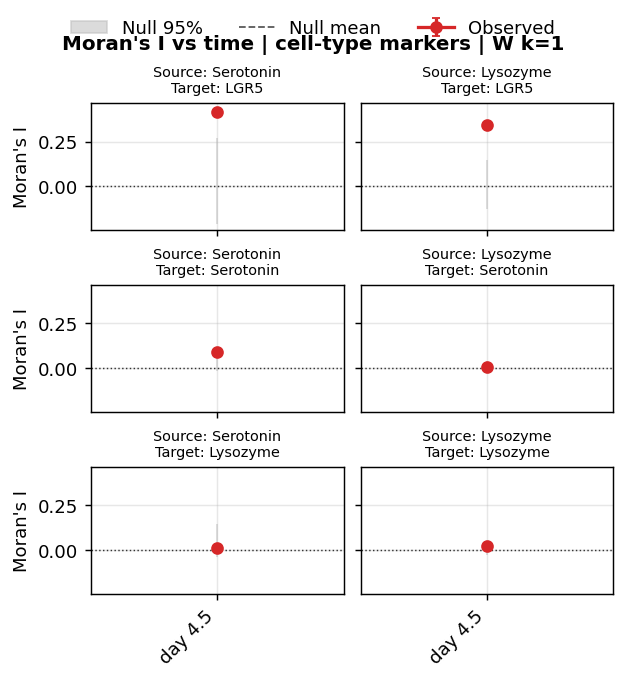

Saved figure: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/plot_marker_neighborhood/morans_I_cell-type_markers_k1.pdf


In [18]:
moran_summaries = {}
for k in MORAN_K_VALUES:
    for analysis in MORAN_ANALYSES:
        fig, axes, summary = plot_moran_grid(moran_df, analysis, k=k)
        export_figure(fig, f"morans_I_{analysis['name']}_k{k}")
        moran_summaries[(analysis["name"], k)] = summary

## K-Hop Neighbor Fractions

This section computes observed k-hop neighbor fractions per organoid. The plotting section below overlays the corresponding shuffled-label expectation for `k=1`.


In [19]:
def knn_cache_path():
    k_tag = "k" + "-".join(map(str, KHOP_K_VALUES))
    suffix = f"{GRAPH_SUBDIR}_{k_tag}_khop_celltype_seed{RANDOM_SEED}_max{MAX_GRAPHS_PER_TIMEPOINT}_markers{marker_preprocess_cache_tag()}.pkl"
    return CACHE_DIR / f"knn_khop_results_{suffix}"


def _knn_neighbor_lists_for_cells(sp_lengths, focal_cells, k):
    """Return all graph nodes within k hops of each focal cell, excluding the focal cell itself."""
    neighbor_lists = []
    for cell in focal_cells:
        dists = sp_lengths.get(int(cell), {})
        neighbors = [int(n) for n, dist in dists.items() if int(n) != int(cell) and 0 < int(dist) <= int(k)]
        neighbor_lists.append(neighbors)
    return neighbor_lists


def _mean_target_fraction_from_neighbors(labels, neighbor_lists, target_indices):
    values = np.zeros((len(neighbor_lists), len(target_indices)), dtype=float)
    labels = np.asarray(labels) > 0
    for i, neighbors in enumerate(neighbor_lists):
        if neighbors:
            values[i, :] = labels[np.asarray(neighbors, dtype=int)][:, target_indices].mean(axis=0)
    return values.mean(axis=0) if len(neighbor_lists) else np.full(len(target_indices), np.nan, dtype=float)


def _khop_marker_composition(G, positive_labels, focal_marker_idx, k):
    labels = (np.asarray(positive_labels) > 0).astype(int)
    focal_cells = np.flatnonzero(labels[:, int(focal_marker_idx)] > 0)
    if focal_cells.size == 0:
        raise ValueError("No cells positive for the focal marker")
    sp_lengths = dict(nx.all_pairs_shortest_path_length(G))
    neighbor_lists = _knn_neighbor_lists_for_cells(sp_lengths, focal_cells, int(k))
    marker_indices = np.arange(labels.shape[1])

    comp_accum = np.zeros((len(neighbor_lists), labels.shape[1]), dtype=float)
    for i, neighbors in enumerate(neighbor_lists):
        if neighbors:
            comp_accum[i, :] = labels[np.asarray(neighbors, dtype=int)][:, marker_indices].mean(axis=0)

    avg_comp = comp_accum.mean(axis=0)
    std_comp = comp_accum.std(axis=0)
    sem_comp = std_comp / np.sqrt(len(focal_cells))
    return avg_comp, std_comp, sem_comp, comp_accum


def compute_knn_results(graph_table, focal_markers=KHOP_FOCAL_MARKERS, target_markers=KHOP_TARGET_MARKERS, k_values=KHOP_K_VALUES):
    cache_path = knn_cache_path()
    if USE_CACHE and cache_path.exists():
        print(f"Loading cached k-hop neighborhood results: {cache_path}")
        with open(cache_path, "rb") as f:
            return filter_to_plot_timepoints(pickle.load(f))

    all_markers = []
    for marker in list(focal_markers) + list(target_markers):
        if marker not in all_markers:
            all_markers.append(marker)

    rows = []
    for _, rec in tqdm(graph_table.iterrows(), total=len(graph_table), desc="k-hop neighborhood graphs"):
        G = load_graph_cached(rec.graph_path)
        X = marker_matrix_for_graph(G, all_markers)
        if X is None:
            continue

        marker_to_idx = {m: i for i, m in enumerate(all_markers)}
        for k in k_values:
            for focal in focal_markers:
                focal_idx = marker_to_idx[focal]
                if np.nansum(X[:, focal_idx]) == 0:
                    continue
                try:
                    avg_comp, std_comp, sem_comp, comp_accum = _khop_marker_composition(
                        G,
                        X.astype(int),
                        focal_marker_idx=focal_idx,
                        k=int(k),
                    )
                except Exception as err:
                    warnings.warn(f"k-hop neighborhood failed for {rec.label_uid} focal={focal} k={k}: {err}")
                    continue

                for target in target_markers:
                    target_idx = marker_to_idx[target]
                    rows.append({
                        "k": int(k),
                        "dataset": rec.dataset,
                        "timepoint": rec.timepoint,
                        "sample_label": rec.sample_label,
                        "time_numeric": float(rec.time_numeric),
                        "label_uid": rec.label_uid,
                        "focal": focal,
                        "target": target,
                        "fraction": float(avg_comp[target_idx]),
                        "n_focal_cells": int(comp_accum.shape[0]),
                    })

    result = pd.DataFrame(rows)
    if USE_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(result, f)
        print(f"Saved k-hop neighborhood cache: {cache_path}")
    return result


knn_df = filter_to_plot_timepoints(compute_knn_results(graph_table))
display(knn_df.head())
display(knn_df.groupby(["k", "sample_label", "focal"]).size().rename("n_values").reset_index())


k-hop neighborhood graphs:   0%|          | 0/627 [00:00<?, ?it/s]

,k,dataset,timepoint,sample_label,time_numeric,label_uid,focal,target,fraction,n_focal_cells
0,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,LGR5,0.544150,93
1,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,Chroma,0.000000,93
2,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,Mucin 2,0.000000,93
3,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,AldoB,0.113228,93
4,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,Glucagon,0.007527,93


,k,sample_label,focal,n_values
0,1,day 4.5,LGR5,4230


## Retained Neighborhood Figures

This section plots two retained neighborhood summaries: observed direct-neighbor marker fractions with shuffled-label expectations, and graph-hop enrichment curves with shuffled-label null ribbons.


In [20]:
# Retained neighborhood visualization helpers. All figure settings live in the configuration cell above.

def safe_log2_ratio(observed, expected, eps=1e-9):
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)
    ratio = np.divide(observed + eps, expected + eps)
    return np.log2(ratio)


def knn_label_shuffle_cache_path(focal_markers=KHOP_FOCAL_MARKERS, target_markers=KHOP_TARGET_MARKERS, k_values=KHOP_K_VALUES, n_perms=KHOP_EXPECTED_N_PERMS):
    focal_tag = "-".join(str(m).replace(" ", "") for m in focal_markers)
    target_tag = "-".join(str(m).replace(" ", "") for m in target_markers)
    k_tag = "k" + "-".join(map(str, k_values))
    suffix = f"{GRAPH_SUBDIR}_{focal_tag}_to_{target_tag}_{k_tag}_khop_perms{int(n_perms)}_seed{RANDOM_SEED}_max{MAX_GRAPHS_PER_TIMEPOINT}_markers{marker_preprocess_cache_tag()}.pkl"
    return CACHE_DIR / f"knn_khop_label_shuffle_expected_{suffix}"


def compute_knn_label_shuffle_expected_results(
    graph_table,
    focal_markers=KHOP_FOCAL_MARKERS,
    target_markers=KHOP_TARGET_MARKERS,
    k_values=KHOP_K_VALUES,
    n_perms=KHOP_EXPECTED_N_PERMS,
    seed=RANDOM_SEED,
):
    cache_path = knn_label_shuffle_cache_path(focal_markers, target_markers, k_values, n_perms)
    if USE_CACHE and cache_path.exists():
        print(f"Loading cached k-hop shuffled-label expectation: {cache_path}")
        with open(cache_path, "rb") as f:
            return filter_to_plot_timepoints(pickle.load(f))

    all_markers = []
    for marker in list(focal_markers) + list(target_markers):
        if marker not in all_markers:
            all_markers.append(marker)

    rows = []
    rng = np.random.default_rng(seed)
    for _, rec in tqdm(graph_table.iterrows(), total=len(graph_table), desc="k-hop shuffled-label null graphs"):
        G = load_graph_cached(rec.graph_path)
        X = marker_matrix_for_graph(G, all_markers)
        if X is None:
            continue
        X = (np.asarray(X) > 0).astype(int)
        n_cells = int(X.shape[0])
        marker_to_idx = {m: i for i, m in enumerate(all_markers)}
        target_indices = [marker_to_idx[target] for target in target_markers]
        target_counts = {target: int(np.nansum(X[:, marker_to_idx[target]] > 0)) for target in target_markers}

        # Generate each shuffled label matrix once per graph, then reuse it for all k/focal/target entries below.
        shuffled_targets = np.empty((int(n_perms), n_cells, len(target_indices)), dtype=int)
        for p in range(int(n_perms)):
            perm_idx = rng.permutation(n_cells)
            shuffled_targets[p] = X[perm_idx][:, target_indices]

        sp_lengths = dict(nx.all_pairs_shortest_path_length(G))
        for k in k_values:
            for focal in focal_markers:
                focal_idx = marker_to_idx[focal]
                focal_cells = np.flatnonzero(X[:, focal_idx] > 0)
                if focal_cells.size == 0:
                    continue
                neighbor_lists = _knn_neighbor_lists_for_cells(sp_lengths, focal_cells, int(k))
                null_fractions = np.full((int(n_perms), len(target_markers)), np.nan, dtype=float)
                for p in range(int(n_perms)):
                    null_fractions[p, :] = _mean_target_fraction_from_neighbors(
                        shuffled_targets[p],
                        neighbor_lists,
                        np.arange(len(target_indices)),
                    )

                expected = np.nanmean(null_fractions, axis=0)
                low, high = np.nanpercentile(null_fractions, [2.5, 97.5], axis=0)
                median = np.nanmedian(null_fractions, axis=0)
                std = np.nanstd(null_fractions, axis=0, ddof=1) if int(n_perms) > 1 else np.full(len(target_markers), np.nan)
                for j, target in enumerate(target_markers):
                    rows.append({
                        "k": int(k),
                        "dataset": rec.dataset,
                        "timepoint": rec.timepoint,
                        "sample_label": rec.sample_label,
                        "time_numeric": float(rec.time_numeric),
                        "label_uid": rec.label_uid,
                        "focal": focal,
                        "target": target,
                        "expected_fraction": float(expected[j]) if np.isfinite(expected[j]) else np.nan,
                        "expected_fraction_null_low": float(low[j]) if np.isfinite(low[j]) else np.nan,
                        "expected_fraction_null_high": float(high[j]) if np.isfinite(high[j]) else np.nan,
                        "expected_fraction_null_median": float(median[j]) if np.isfinite(median[j]) else np.nan,
                        "expected_fraction_null_std": float(std[j]) if np.isfinite(std[j]) else np.nan,
                        "n_perms": int(n_perms),
                        "n_focal_cells": int(focal_cells.size),
                        "target_n_positive": target_counts[target],
                        "graph_n_cells": n_cells,
                    })

    result = pd.DataFrame(rows)
    if USE_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(result, f)
        print(f"Saved k-hop shuffled-label expectation cache: {cache_path}")
    return filter_to_plot_timepoints(result)


def add_knn_expected_and_enrichment(knn_df, expected_df):
    merge_cols = ["k", "dataset", "timepoint", "sample_label", "time_numeric", "label_uid", "focal", "target"]
    expected_cols = merge_cols + [
        "expected_fraction",
        "expected_fraction_null_low",
        "expected_fraction_null_high",
        "expected_fraction_null_median",
        "expected_fraction_null_std",
        "n_perms",
        "target_n_positive",
        "graph_n_cells",
    ]
    out = knn_df.merge(expected_df[expected_cols], on=merge_cols, how="left")
    out["enrichment"] = np.divide(
        out["fraction"],
        out["expected_fraction"],
        out=np.full(len(out), np.nan, dtype=float),
        where=out["expected_fraction"].to_numpy(dtype=float) > 0,
    )
    out["log2_enrichment"] = safe_log2_ratio(out["fraction"], out["expected_fraction"])
    return out


def summarize_knn_enrichment(enriched_df, k, focal_markers=KHOP_FOCAL_MARKERS, target_markers=KHOP_TARGET_MARKERS):
    rows = []
    df = enriched_df[enriched_df["k"] == int(k)]
    for sample_label in TIMEPOINT_ORDER:
        for focal in focal_markers:
            for target in target_markers:
                sub = df[(df["sample_label"] == sample_label) & (df["focal"] == focal) & (df["target"] == target)]
                row = {"sample_label": sample_label, "focal": focal, "target": target}
                for col in ["fraction", "expected_fraction", "log2_enrichment", "enrichment"]:
                    vals = sub[col].to_numpy(dtype=float) if col in sub else np.array([], dtype=float)
                    if vals.size == 0:
                        mean = sem = np.nan
                        n = 0
                    else:
                        mean, sem, n = mean_sem(vals, axis=0)
                    row[f"{col}_mean"] = float(mean) if np.isfinite(mean) else np.nan
                    row[f"{col}_sem"] = float(sem) if np.isfinite(sem) else np.nan
                    row[f"{col}_n_graphs"] = int(n)
                obs_mean = row.get("fraction_mean", np.nan)
                exp_mean = row.get("expected_fraction_mean", np.nan)
                if np.isfinite(obs_mean) and np.isfinite(exp_mean) and exp_mean > 0:
                    row["enrichment_ratio_of_means"] = float(obs_mean / exp_mean)
                    row["log2_ratio_of_means"] = float(safe_log2_ratio(obs_mean, exp_mean))
                else:
                    row["enrichment_ratio_of_means"] = np.nan
                    row["log2_ratio_of_means"] = np.nan
                rows.append(row)
    return pd.DataFrame(rows)



def plot_knn_observed_vs_expected(enriched_df, k=1, focal_markers=KHOP_FOCAL_MARKERS, target_markers=KHOP_TARGET_MARKERS):
    summary = summarize_knn_enrichment(enriched_df, k, focal_markers, target_markers)
    n_tp = len(TIMEPOINT_ORDER)
    ncols = min(3, n_tp)
    nrows = int(np.ceil(n_tp / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.25 * ncols, 2.75 * nrows),
        sharey=True,
        constrained_layout=True,
        squeeze=False,
    )
    axes = axes.ravel()
    x = np.arange(len(target_markers))
    width = 0.78 / max(1, len(focal_markers))
    colors = dict(zip(focal_markers, plt.get_cmap("tab10").colors[:len(focal_markers)]))
    for ax, sample_label in zip(axes, TIMEPOINT_ORDER):
        for i, focal in enumerate(focal_markers):
            sub = (
                summary[(summary["sample_label"] == sample_label) & (summary["focal"] == focal)]
                .set_index("target")
                .reindex(target_markers)
            )
            xpos = x + (i - (len(focal_markers) - 1) / 2.0) * width
            obs = sub["fraction_mean"].to_numpy(dtype=float)
            obs_sem = sub["fraction_sem"].to_numpy(dtype=float)
            exp = sub["expected_fraction_mean"].to_numpy(dtype=float)

            ax.bar(
                xpos,
                obs,
                yerr=obs_sem,
                width=width,
                color=colors[focal],
                alpha=0.82,
                capsize=2,
                label=focal,
            )
            ax.scatter(
                xpos,
                exp,
                color="black",
                marker="_",
                s=150,
                linewidths=1.7,
                label="expected from shuffled labels" if i == 0 else None,
            )
        ax.set_ylim(0, 1)
        ax.set_title(sample_label, fontsize=10, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(target_markers, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.25, which="both")
        box_on(ax)
        ax.set_ylabel("fraction of k-hop neighbors positive")

    for ax in axes[n_tp:]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        seen = set()
        uniq_handles, uniq_labels = [], []
        for handle, label in zip(handles, labels):
            if label and label not in seen:
                uniq_handles.append(handle)
                uniq_labels.append(label)
                seen.add(label)
        fig.legend(
            uniq_handles,
            uniq_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.03),
            ncol=min(len(uniq_labels), len(focal_markers) + 1),
            frameon=False,
        )
    fig.suptitle(f"Observed k-hop marker fraction vs shuffled-label expectation | k={k}", fontsize=11, fontweight="bold")
    plt.show()
    return fig, axes, summary


def hop_pair_cache_path(pairs=HOP_ENRICHMENT_PAIRS):
    pair_tag = "-".join(f"{a}_to_{b}".replace(" ", "") for a, b in pairs)
    suffix = f"{GRAPH_SUBDIR}_{pair_tag}_hops{HOP_ENRICHMENT_MAX_HOPS}_perms{HOP_NULL_PERMS}_nullmean_seed{RANDOM_SEED}_max{MAX_GRAPHS_PER_TIMEPOINT}_markers{marker_preprocess_cache_tag()}.pkl"
    return CACHE_DIR / f"hop_pair_enrichment_{suffix}"


def graph_hop_pair_enrichment_with_null(G, source_marker, target_marker, max_hops=HOP_ENRICHMENT_MAX_HOPS, n_perms=HOP_NULL_PERMS, rng=None):
    processed_marker_names = list(G.graph.get("marker_names", []))
    processed_markers_bin = np.asarray(graph_get(G, "markers_bin"))
    markers_eff, marker_names_eff = effective_marker_matrix(processed_markers_bin, processed_marker_names)
    source = marker_vector(markers_eff, marker_names_eff, source_marker)
    target = marker_vector(markers_eff, marker_names_eff, target_marker)
    if source is None or target is None:
        return None
    source_nodes = np.flatnonzero(source.astype(bool))
    if source_nodes.size == 0:
        return None
    global_target_fraction = float(np.nanmean(target))
    if not np.isfinite(global_target_fraction) or global_target_fraction <= 0:
        return None

    shell_nodes = [[] for _ in range(int(max_hops) + 1)]
    for node in source_nodes:
        lengths = nx.single_source_shortest_path_length(G, int(node), cutoff=int(max_hops))
        for nb, dist in lengths.items():
            d = int(dist)
            if 0 <= d <= int(max_hops):
                shell_nodes[d].append(int(nb))

    observed = np.full(int(max_hops) + 1, np.nan, dtype=float)
    counts = np.zeros(int(max_hops) + 1, dtype=float)
    for d, nodes in enumerate(shell_nodes):
        if nodes:
            idx = np.asarray(nodes, dtype=int)
            counts[d] = idx.size
            observed[d] = np.nanmean(target[idx]) / global_target_fraction

    rng = np.random.default_rng(RANDOM_SEED) if rng is None else rng
    null_curves = np.full((int(n_perms), int(max_hops) + 1), np.nan, dtype=float)
    target_arr = np.asarray(target, dtype=float)
    for p in range(int(n_perms)):
        shuffled = rng.permutation(target_arr)
        for d, nodes in enumerate(shell_nodes):
            if nodes:
                idx = np.asarray(nodes, dtype=int)
                null_curves[p, d] = np.nanmean(shuffled[idx]) / global_target_fraction
    low, high = np.nanpercentile(null_curves, HOP_NULL_Q, axis=0)
    mean = np.nanmean(null_curves, axis=0)
    return observed, low, high, mean, counts


def compute_hop_pair_enrichment_results(graph_table, pairs=HOP_ENRICHMENT_PAIRS, max_hops=HOP_ENRICHMENT_MAX_HOPS, n_perms=HOP_NULL_PERMS):
    cache_path = hop_pair_cache_path(pairs)
    if USE_CACHE and cache_path.exists():
        print(f"Loading cached hop pair enrichment results: {cache_path}")
        with open(cache_path, "rb") as f:
            return filter_to_plot_timepoints(pickle.load(f))

    rows = []
    rng = np.random.default_rng(RANDOM_SEED)
    for _, rec in tqdm(graph_table.iterrows(), total=len(graph_table), desc="Hop-pair enrichment graphs"):
        G = load_graph_cached(rec.graph_path)
        if G.number_of_nodes() < 3 or G.number_of_edges() == 0:
            continue
        for source, target in pairs:
            out = graph_hop_pair_enrichment_with_null(G, source, target, max_hops=max_hops, n_perms=n_perms, rng=rng)
            if out is None:
                continue
            observed, low, high, mean, counts = out
            rows.append({
                "dataset": rec.dataset,
                "timepoint": rec.timepoint,
                "sample_label": rec.sample_label,
                "time_numeric": float(rec.time_numeric),
                "label_uid": rec.label_uid,
                "source": source,
                "target": target,
                "observed_enrichment": observed.astype(float),
                "null_low": low.astype(float),
                "null_high": high.astype(float),
                "null_mean": mean.astype(float),
                "total_counts": counts.astype(float),
            })
    result = pd.DataFrame(rows)
    if USE_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(result, f)
        print(f"Saved hop pair enrichment cache: {cache_path}")
    return filter_to_plot_timepoints(result)


def summarize_hop_pair_enrichment(hop_df, pairs=HOP_ENRICHMENT_PAIRS, max_hops=HOP_ENRICHMENT_MAX_HOPS):
    rows = []
    for sample_label in TIMEPOINT_ORDER:
        for source, target in pairs:
            sub = hop_df[(hop_df["sample_label"] == sample_label) & (hop_df["source"] == source) & (hop_df["target"] == target)]
            if sub.empty:
                obs_mean = obs_sem = low = high = null_mean = np.full(int(max_hops) + 1, np.nan, dtype=float)
                n = np.zeros(int(max_hops) + 1, dtype=int)
            else:
                obs = np.stack(sub["observed_enrichment"].to_numpy(), axis=0).astype(float)
                low_arr = np.stack(sub["null_low"].to_numpy(), axis=0).astype(float)
                high_arr = np.stack(sub["null_high"].to_numpy(), axis=0).astype(float)
                mean_arr = np.stack(sub["null_mean"].to_numpy(), axis=0).astype(float)
                obs_mean, obs_sem, n = mean_sem(obs, axis=0)
                low = np.nanmean(low_arr, axis=0)
                high = np.nanmean(high_arr, axis=0)
                null_mean = np.nanmean(mean_arr, axis=0)
            for d in range(int(max_hops) + 1):
                rows.append({
                    "sample_label": sample_label,
                    "source": source,
                    "target": target,
                    "distance_hops": d,
                    "observed_mean": float(obs_mean[d]) if np.isfinite(obs_mean[d]) else np.nan,
                    "observed_sem": float(obs_sem[d]) if np.isfinite(obs_sem[d]) else np.nan,
                    "null_low_mean": float(low[d]) if np.isfinite(low[d]) else np.nan,
                    "null_high_mean": float(high[d]) if np.isfinite(high[d]) else np.nan,
                    "null_mean": float(null_mean[d]) if np.isfinite(null_mean[d]) else np.nan,
                    "n_graphs": int(n[d]),
                })
    return pd.DataFrame(rows)


def plot_hop_pair_enrichment_ribbons(hop_df, pairs=HOP_ENRICHMENT_PAIRS, max_hops=HOP_ENRICHMENT_MAX_HOPS, min_hop=HOP_MIN_HOP):
    summary = summarize_hop_pair_enrichment(hop_df, pairs=pairs, max_hops=max_hops)
    panels = [(source, target, sample_label) for source, target in pairs for sample_label in TIMEPOINT_ORDER]
    ncols = 3
    nrows = max(1, int(np.ceil(len(panels) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 2.25 * nrows), sharex=True, sharey=True, constrained_layout=True, squeeze=False)
    axes_flat = axes.ravel()
    legend_handles = None
    legend_labels = None
    for panel_idx, (ax, (source, target, sample_label)) in enumerate(zip(axes_flat, panels)):
        sub = summary[
            (summary["source"] == source)
            & (summary["target"] == target)
            & (summary["sample_label"] == sample_label)
            & (summary["distance_hops"] >= int(min_hop))
        ].sort_values("distance_hops")
        if sub.empty:
            ax.axis("off")
            continue
        x = sub["distance_hops"].to_numpy(dtype=float)
        y = sub["observed_mean"].to_numpy(dtype=float)
        se = sub["observed_sem"].to_numpy(dtype=float)
        lo = sub["null_low_mean"].to_numpy(dtype=float)
        hi = sub["null_high_mean"].to_numpy(dtype=float)
        null_mean = sub["null_mean"].to_numpy(dtype=float)
        ax.fill_between(x, lo, hi, color="0.75", alpha=0.55, linewidth=0, label="shuffled 95% interval")
        ax.plot(x, null_mean, color="0.35", linestyle=":", linewidth=1.0, label="null mean")
        ax.plot(x, y, marker="o", color="#b2182b", linewidth=1.5, markersize=3.0, label="observed")
        ax.fill_between(x, y - se, y + se, color="#b2182b", alpha=0.18, linewidth=0)
        ax.axhline(1.0, color="0.2", linestyle="--", linewidth=0.8)
        ax.set_title(f"{sample_label}\n{source}+ -> {target}+", fontsize=8.5, fontweight="bold")
        ax.grid(alpha=0.25)
        box_on(ax)
        if panel_idx % ncols == 0:
            ax.set_ylabel("enrichment")
        if panel_idx >= max(0, len(panels) - ncols):
            ax.set_xlabel("graph hops")
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
    for ax in axes_flat[len(panels):]:
        ax.axis("off")
    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)
    fig.suptitle("Graph-hop enrichment with shuffled-label null", fontsize=11, fontweight="bold")
    plt.show()
    return fig, axes, summary


k-hop shuffled-label null graphs:   0%|          | 0/627 [00:00<?, ?it/s]

,k,dataset,timepoint,sample_label,time_numeric,label_uid,focal,target,fraction,n_focal_cells,expected_fraction,expected_fraction_null_low,expected_fraction_null_high,expected_fraction_null_median,expected_fraction_null_std,n_perms,target_n_positive,graph_n_cells,enrichment,log2_enrichment
0,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,LGR5,0.544150,93,0.205062,0.160553,0.266281,0.201400,0.041707,7,93,439,2.653590,1.407946
1,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,Chroma,0.000000,93,0.000000,0.000000,0.000000,0.000000,0.000000,7,0,439,NaN,0.000000
2,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,Mucin 2,0.000000,93,0.000000,0.000000,0.000000,0.000000,0.000000,7,0,439,NaN,0.000000
3,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,AldoB,0.113228,93,0.475629,0.404187,0.518484,0.484857,0.041032,7,199,439,0.238058,-2.070612
4,1,20250929,day4p5-more,day 4.5,4.5,day4p5-more_C01_1,LGR5,Glucagon,0.007527,93,0.002781,0.000000,0.007300,0.002880,0.002988,7,1,439,2.706114,1.436223


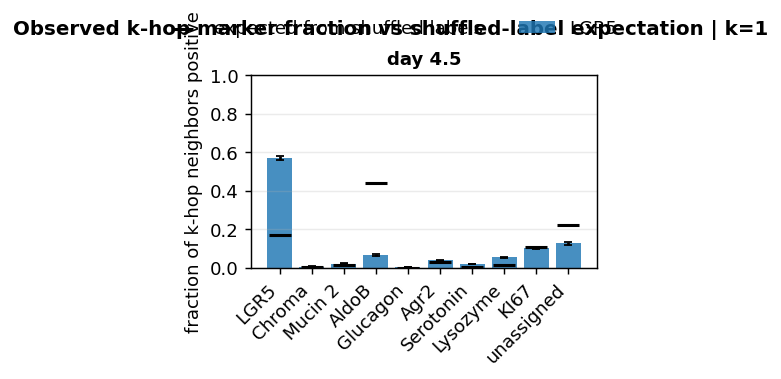

Saved figure: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/plot_marker_neighborhood/knn_observed_vs_expected_k1.pdf


Hop-pair enrichment graphs:   0%|          | 0/627 [00:00<?, ?it/s]

/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/tmp/ipykernel_19412/3770197947.py:287: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(null_curves, axis=0)


,sample_label,source,target,distance_hops,observed_mean,observed_sem,null_low_mean,null_high_mean,null_mean,n_graphs
0,day 4.5,LGR5,LGR5,0,27.719360,3.229278,0.423829,2.793481,0.998537,423
1,day 4.5,LGR5,LGR5,1,6.073873,0.300663,0.498001,2.395254,0.996258,423
2,day 4.5,LGR5,LGR5,2,4.453164,0.170863,0.543534,2.298417,0.999369,423
3,day 4.5,LGR5,LGR5,3,3.180722,0.096930,0.588696,2.133655,1.002257,423
4,day 4.5,LGR5,LGR5,4,2.308504,0.070847,0.629904,1.921883,0.999471,423


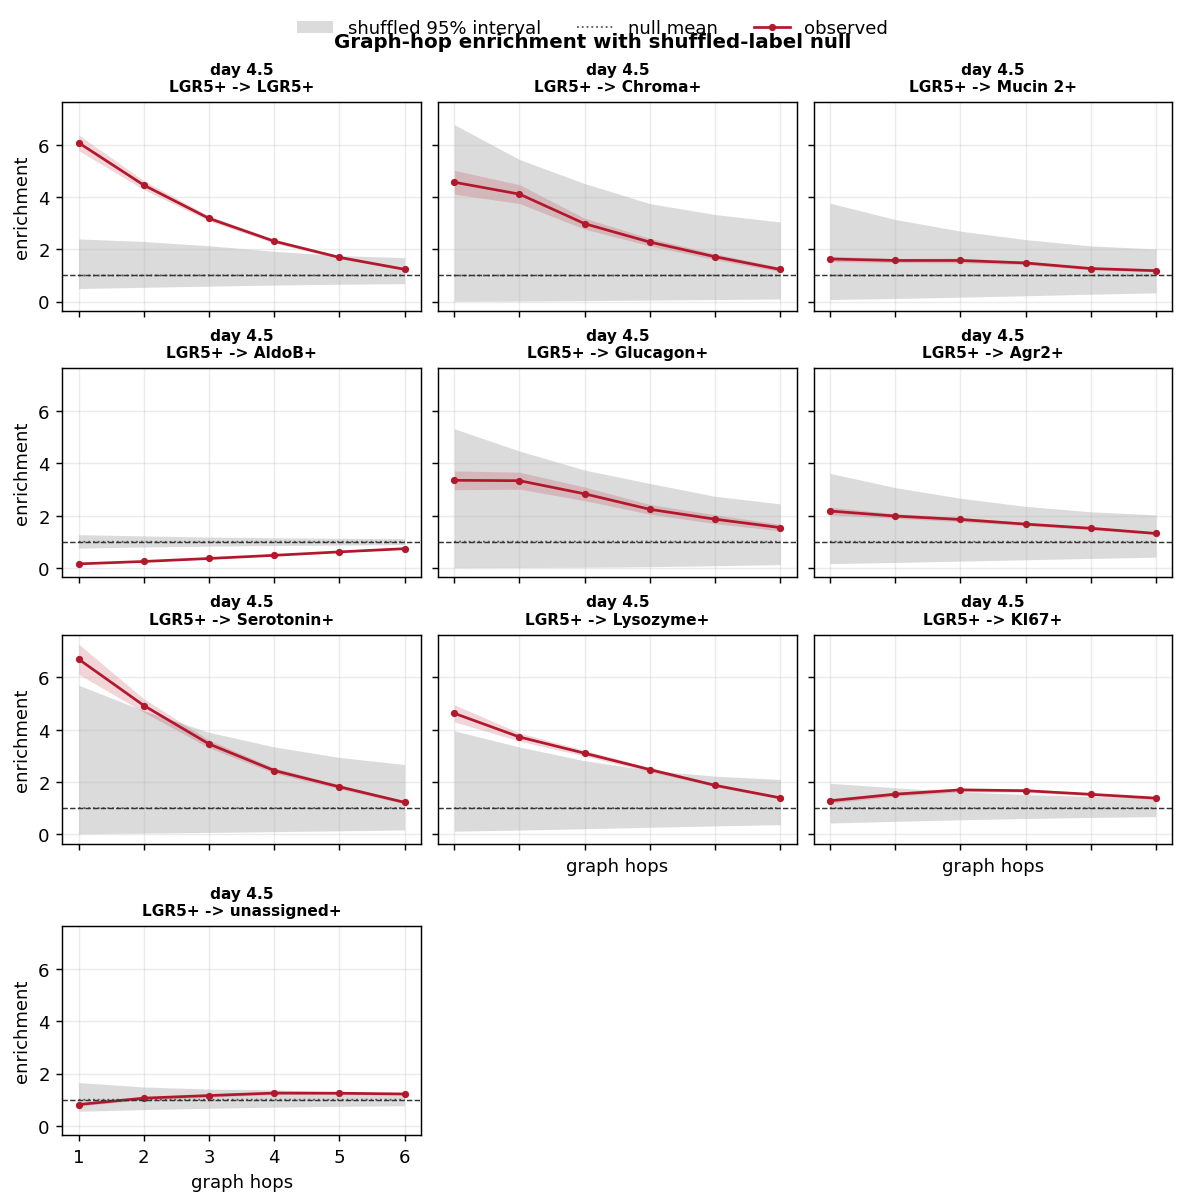

Saved figure: /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/plot_marker_neighborhood/hop_pair_enrichment_shuffled_null_ribbons.pdf


PosixPath('/home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/plot_marker_neighborhood/hop_pair_enrichment_shuffled_null_ribbons.pdf')

In [21]:
knn_expected_df = compute_knn_label_shuffle_expected_results(graph_table)
knn_enriched_df = add_knn_expected_and_enrichment(knn_df, knn_expected_df)
display(knn_enriched_df.head())

knn_enrichment_summaries = {}
for k in KHOP_K_VALUES:
    if int(k) != int(KHOP_PLOT_K):
        continue
    fig, axes, summary = plot_knn_observed_vs_expected(knn_enriched_df, k=k)
    export_figure(fig, f"knn_observed_vs_expected_k{k}")
    knn_enrichment_summaries[("observed_vs_expected", k)] = summary

hop_pair_enrichment_df = compute_hop_pair_enrichment_results(graph_table, HOP_ENRICHMENT_PAIRS)
hop_pair_enrichment_summary = summarize_hop_pair_enrichment(hop_pair_enrichment_df, HOP_ENRICHMENT_PAIRS)
display(hop_pair_enrichment_summary.head())
fig, axes, hop_pair_enrichment_summary = plot_hop_pair_enrichment_ribbons(hop_pair_enrichment_df, HOP_ENRICHMENT_PAIRS)
export_figure(fig, "hop_pair_enrichment_shuffled_null_ribbons")


## Export Tables (Optional)

In [22]:
moran_df.drop(columns=["I_perm"]).to_csv(EXPORT_DIR / "moran_observed_values.csv", index=False)
for (analysis_name, k), summary in moran_summaries.items():
    safe_name = analysis_name.replace(" ", "_").replace("/", "_")
    summary.to_csv(EXPORT_DIR / f"moran_summary_{safe_name}_k{k}.csv", index=False)

def hop_pair_enrichment_to_long(hop_df):
    rows = []
    if hop_df is None or hop_df.empty:
        return pd.DataFrame(rows)
    base_cols = ["dataset", "timepoint", "sample_label", "time_numeric", "label_uid", "source", "target"]
    curve_cols = ["observed_enrichment", "null_low", "null_high", "null_mean", "total_counts"]
    for _, rec in hop_df.iterrows():
        curves = {col: np.asarray(rec[col], dtype=float) for col in curve_cols}
        n_hops = len(curves["observed_enrichment"])
        for distance_hops in range(n_hops):
            row = {col: rec[col] for col in base_cols}
            row["distance_hops"] = int(distance_hops)
            for col in curve_cols:
                value = curves[col][distance_hops]
                row[col] = float(value) if np.isfinite(value) else np.nan
            rows.append(row)
    return pd.DataFrame(rows)


knn_df.to_csv(EXPORT_DIR / "knn_organoid_values.csv", index=False)
if "knn_expected_df" in globals():
    knn_expected_df.to_csv(EXPORT_DIR / "knn_shuffled_expected_organoid_values.csv", index=False)
if "knn_enriched_df" in globals():
    knn_enriched_df.to_csv(EXPORT_DIR / "knn_enriched_organoid_values.csv", index=False)
    knn_enriched_df.to_csv(EXPORT_DIR / "khop_neighbor_fraction_organoid_plot_data.csv", index=False)
if "knn_enrichment_summaries" in globals():
    khop_summary_tables = []
    for (view_name, k), summary in knn_enrichment_summaries.items():
        summary.to_csv(EXPORT_DIR / f"knn_enrichment_summary_{view_name}_k{k}.csv", index=False)
        table = summary.copy()
        table.insert(0, "view_name", view_name)
        table.insert(1, "k", int(k))
        khop_summary_tables.append(table)
    if khop_summary_tables:
        pd.concat(khop_summary_tables, ignore_index=True).to_csv(EXPORT_DIR / "khop_neighbor_fraction_summary_plot_data.csv", index=False)

if "hop_pair_enrichment_df" in globals():
    hop_pair_enrichment_df.to_csv(EXPORT_DIR / "hop_pair_enrichment_organoid_values.csv", index=False)
    hop_pair_enrichment_long_df = hop_pair_enrichment_to_long(hop_pair_enrichment_df)
    hop_pair_enrichment_long_df.to_csv(EXPORT_DIR / "hop_enrichment_organoid_long_plot_data.csv", index=False)
if "hop_pair_enrichment_summary" in globals():
    hop_pair_enrichment_summary.to_csv(EXPORT_DIR / "hop_pair_enrichment_summary.csv", index=False)
    hop_pair_enrichment_summary.to_csv(EXPORT_DIR / "hop_enrichment_summary_plot_data.csv", index=False)

print(f"Exported retained summary tables to {EXPORT_DIR}")


Exported retained summary tables to /home/fmoller/Projects/LearningOrganoids/OrganoGraph/exports/plot_marker_neighborhood
